## HW 7

In [3]:
import os
import requests
import zipfile

url = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true"
zip_file_path = "SpamEmailClassificationDataset.zip"
csv_file_name = "combined_data.csv"

if not os.path.exists(csv_file_name):
    response = requests.get(url) 
    
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
        
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    os.remove(zip_file_path)

In [4]:
import pandas as pd
df_file_path = os.path.join('./SpamEmailClassificationDataset/', csv_file_name)
df = pd.read_csv(df_file_path)
print(f"Shape: {df.shape}")
print(df.head(10))
print(df.info())

Shape: (14861, 2)
   label                                               text
0  label                                               text
1      1  ounce feather bowl hummingbird opec moment ala...
2      1  wulvob get your medircations online qnb ikud v...
3      0   computer connection from cnn com wednesday es...
4      1  university degree obtain a prosperous future m...
5      0  thanks for all your answers guys i know i shou...
6      0  larry king live at escapenumber escapenumber p...
7      0  michael pobega wrote i'm not sure if it's the ...
8      0  hi i have this error tr sample escapenumber es...
9      1  works gateway world art explore tattooing full...
<class 'pandas.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   14861 non-null  str  
 1   text    14861 non-null  str  
dtypes: str(2)
memory usage: 232.3 KB
None


### Splitting the dataset

In [5]:
# Filter by label + get samples 
df_spam = df[df['label'] == '1'].sample(n=1500, random_state=42)
df_ham = df[df['label'] == '0'].sample(n=1500, random_state=42)

#  Merge datasets
df_sliced = pd.concat([df_spam, df_ham])

# Mixing records
df_sliced = df_sliced.sample(frac=1, random_state=42).reset_index(drop=True)
df_sliced

,label,text
0,0,dave will continue to have the friday afternoo...
1,1,need in software for your pc ? just visit our ...
2,0,on escapenumber escapenumber escapenumber arne...
3,1,if this is your wife then it is already too la...
4,0,hello everyone i want to calculate an instrume...
...,...,...
2995,0,begin pgp signed message hash shaescapenumber...
2996,1,lese selbst :\neu - abgeordnete goennen sich l...
2997,1,flame may month look may black some responsibl...
2998,1,if you cannot adequately view this message ple...


### Distribution Visualization

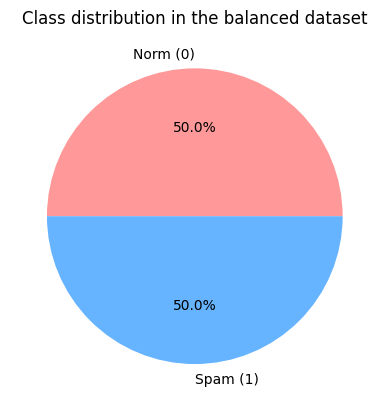

In [13]:
import matplotlib.pyplot as plt

df_sliced['label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'], 
    labels=['Norm (0)', 'Spam (1)'] 
)

plt.title("Class distribution in the balanced dataset")
plt.show()

### Preprosessing

In [ ]:
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

corpus = []
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

for document in df_sliced["text"]:
    document = re.sub("[^a-zA-Z]", " ", document).lower()
    document = document.split()
    document = [lemmatizer.lemmatize(word) for word in document if word not in stop_words]
    # print(document)
    document = list(set(document))
    document = " ".join(document)
    corpus.append(document)

df_sliced["text"] = corpus

print(df_sliced.head(5))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ElizabethSheremet\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ElizabethSheremet\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ElizabethSheremet\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Package wordnet is already up-to-date!


  label                                               text
0     0  continue pm time feel april effective bev aril...
1     1  shery might site best pc software visit need r...
2     0  darkblue said arne inside display set org mail...
3     1  husband intended distribution disclosure sale ...
4     0  calculate using exclude posting instrumental u...
